In [1]:
import pandas as pd
import numpy as np
from tsfresh import extract_features
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.feature_extraction.feature_calculators import mean
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import optuna
# import kan 
# import pykan
# from kan import KAN
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from tsfresh.feature_extraction import ComprehensiveFCParameters
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
import re
from pathlib import Path
from PIL import Image
import numpy as np
import random
from collections import Counter
from torch.utils.data import Dataset, DataLoader, random_split

/opt/venvs/torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
base_path = Path("../Lamina")
train_dir =  base_path / "train"

# === 2. Listar imagens ===
image_paths = sorted(list(train_dir.glob("*.png")))
print(f"Total de imagens encontradas: {len(image_paths)}")

Total de imagens encontradas: 1100


In [3]:
import cv2
import numpy as np
from pathlib import Path

base_path = Path("../Lamina")
train_dir = base_path / "train"

image_paths = sorted(list(train_dir.glob("*.png")))
print(f"Total de imagens encontradas: {len(image_paths)}")

imgs = []

for p in image_paths:
    img_bgr = cv2.imread(str(p))            # lê em BGR (uint8)
    if img_bgr is None:
        print("Falha ao ler:", p)
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # BGR -> RGB
    imgs.append(img_rgb)

# Empilha numa array (N, H, W, 3)
rgb_array = np.stack(imgs, axis=0)  # ainda uint8
print("rgb_array shape:", rgb_array.shape)
rgb_array = rgb_array.astype(np.float32) / 255.0
print("dtype:", rgb_array.dtype, "min/max:", rgb_array.min(), rgb_array.max())


Total de imagens encontradas: 1100
rgb_array shape: (1100, 256, 256, 3)
dtype: float32 min/max: 0.0 1.0


In [4]:
np.save("rgb_sem_filtro", rgb_array)

In [20]:
class_labels = []
for path in image_paths:
    class_labels.append(path.name.split('_')[4])
len(class_labels)

1100

In [24]:
# === Create dictionary {filename: {"image": matrix, "class": label}} ===
data_dict = {}

for path in image_paths:
    # Extract class label (5th token in filename)
    label = path.name.split('_')[4]
    
    # Load image in RGB and convert to numpy array
    img = Image.open(path).convert("RGB")
    img_array = np.array(img, dtype=np.uint8)  # shape (H, W, 3)
    
    # Store in dictionary
    data_dict[path.name] = {
        "image": img_array,
        "class": label
    }

# === 4. Example: inspect one sample ===
sample_key = list(data_dict.keys())[0]
print(f"Sample name: {sample_key}")
print(f"Class: {data_dict[sample_key]['class']}")
print(f"Image shape: {data_dict[sample_key]['image'].shape}")

Sample name: PBGAN_seed0006_PP_None_RET_cropped_tl.png
Class: RET
Image shape: (256, 256, 3)


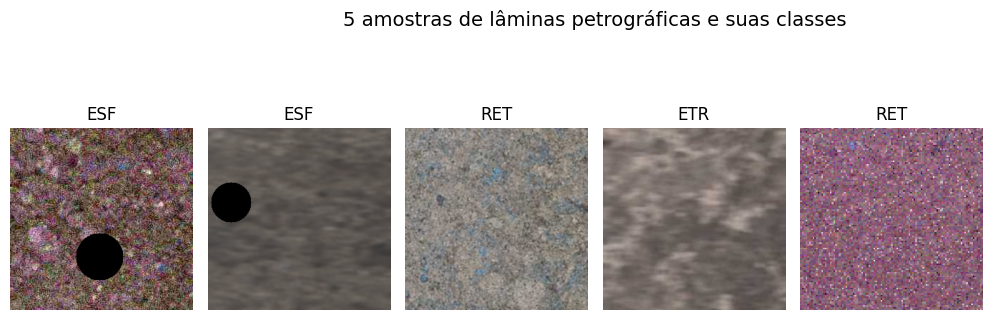

In [73]:
# Selecionar 5 chaves aleatórias do dicionário
sample_keys = random.sample(list(data_dict.keys()), 5)

plt.figure(figsize=(12, 4))

for i, key in enumerate(sample_keys):
    img = data_dict[key]["image"]
    label = data_dict[key]["class"]
    
    plt.subplot(1, 6, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.suptitle("5 amostras de lâminas petrográficas e suas classes", fontsize=14)
plt.tight_layout()
plt.show()

In [51]:
import torchvision.transforms as T

In [49]:
class LaminaDataset(Dataset):
    def __init__(self, data_dict, transform=None):
        self.keys = list(data_dict.keys())
        self.data = data_dict
        self.transform = transform
        
        # Obter classes únicas e mapear para índices
        self.classes = sorted(list(set(d["class"] for d in data_dict.values())))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, idx):
        key = self.keys[idx]
        item = self.data[key]
        img = item["image"]
        label = self.class_to_idx[item["class"]]
        
        # Converter NumPy para PIL e aplicar transformações
        from PIL import Image
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        
        return img, label

In [52]:
transform = T.Compose([
    T.Resize((128, 128)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [53]:
transform

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

In [54]:
dataset = LaminaDataset(data_dict, transform=transform)

In [56]:
print(f"Total de amostras: {len(dataset)}")
print(f"Classes detectadas: {dataset.classes}")

Total de amostras: 1100
Classes detectadas: ['ESF', 'ETR', 'LMT', 'RET']


Total de amostras: 1100
Classes detectadas: ['ESF', 'ETR', 'LMT', 'RET']
ESF: 100 amostras
ETR: 350 amostras
LMT: 50 amostras
RET: 600 amostras


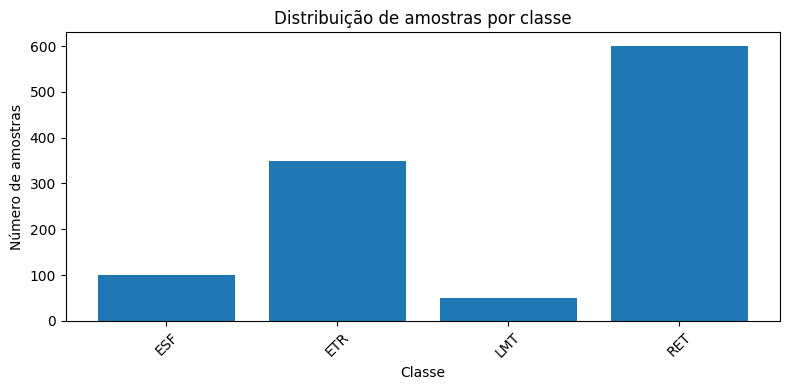

In [59]:
# === Estatísticas básicas ===
print(f"Total de amostras: {len(dataset)}")
print(f"Classes detectadas: {dataset.classes}")

# === Contar amostras por classe ===
class_counts = Counter([label for _, label in dataset])
for i, class_name in enumerate(dataset.classes):
    print(f"{class_name}: {class_counts[i]} amostras")

# === Visualizar em gráfico de barras ===
plt.figure(figsize=(8, 4))
plt.bar(dataset.classes, [class_counts[i] for i in range(len(dataset.classes))])
plt.title("Distribuição de amostras por classe")
plt.xlabel("Classe")
plt.ylabel("Número de amostras")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# ======================================================
# 4. Definir modelo CNN simples
# ======================================================
class LaminaCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

num_classes = len(dataset.classes)
model = LaminaCNN(num_classes)
print(model)

LaminaCNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [91]:
# ======================================================
# 5. Treinamento
# ======================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 15

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # --- Validação ---
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
    
    val_acc = correct / len(val_dataset)
    print(f"Epoch [{epoch+1}/{n_epochs}] | Train Loss: {total_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.3f}")

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor


=== Métricas detalhadas ===
              precision    recall  f1-score   support

         ESF      0.000     0.000     0.000        19
         ETR      0.583     0.515     0.547        68
         LMT      0.000     0.000     0.000        12
         RET      0.669     0.884     0.762       121

    accuracy                          0.645       220
   macro avg      0.313     0.350     0.327       220
weighted avg      0.548     0.645     0.588       220



/opt/venvs/torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/venvs/torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/venvs/torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


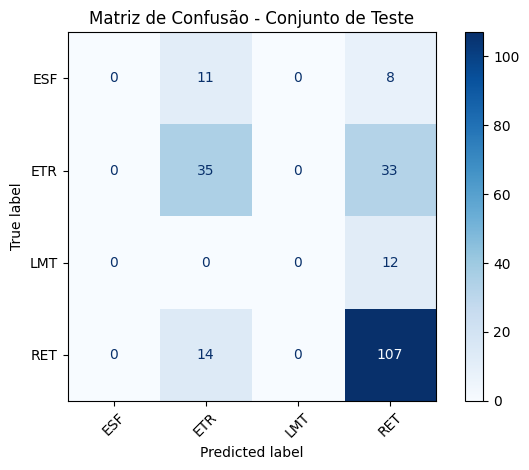

In [92]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# === 1. Avaliar modelo no conjunto de teste ===
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# === 2. Relatório de métricas ===
print("\n=== Métricas detalhadas ===")
print(classification_report(
    y_true, 
    y_pred, 
    target_names=dataset.classes, 
    digits=3
))

# === 3. Matriz de confusão ===
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - Conjunto de Teste")
plt.tight_layout()
plt.show()

### Test

In [78]:
base_path = Path("../Lamina")
train_dir =  base_path / "test"

# === 2. Listar imagens ===
image_paths_test = sorted(list(train_dir.glob("*.png")))
print(f"Total de imagens encontradas: {len(image_paths_test)}")

Total de imagens encontradas: 446


In [82]:
# === 3. Criar dicionário {filename: {"image": matrix}} ===
test_dict = {}

for path in image_paths_test:
    img = Image.open(path).convert("RGB")
    img_array = np.array(img, dtype=np.uint8)
    test_dict[path.name] = {"image": img_array}

# === 4. Exemplo: inspecionar uma amostra ===
sample_key = list(test_dict.keys())[0]
print(f"Sample name: {sample_key}")
print(f"Image shape: {test_dict[sample_key]['image'].shape}")

Sample name: img_20251030_013629_885723.png
Image shape: (512, 512, 3)


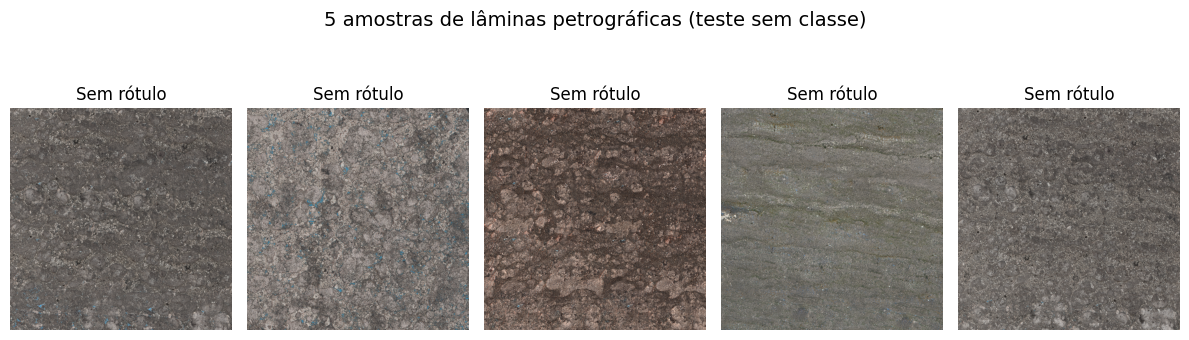

In [85]:
# === 5. Mostrar 5 imagens aleatórias ===
sample_keys = random.sample(list(test_dict.keys()), 5)

plt.figure(figsize=(12, 4))
for i, key in enumerate(sample_keys):
    img = test_dict[key]["image"]
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title("Sem rótulo")
    plt.axis("off")

plt.suptitle("5 amostras de lâminas petrográficas (teste sem classe)", fontsize=14)
plt.tight_layout()
plt.show()